In [25]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [26]:
sales=pd.read_csv(r"C:\Users\rajen\OneDrive\Desktop\Chocolate_Sales\data\sales.csv")
stores=pd.read_csv(r"C:\Users\rajen\OneDrive\Desktop\Chocolate_Sales\data\stores.csv")
customers=pd.read_csv(r"C:\Users\rajen\OneDrive\Desktop\Chocolate_Sales\data\customers.csv")
products=pd.read_csv(r"C:\Users\rajen\OneDrive\Desktop\Chocolate_Sales\data\products.csv")
calendar=pd.read_csv(r"C:\Users\rajen\OneDrive\Desktop\Chocolate_Sales\data\calendar.csv")

In [27]:
sales.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [28]:
stores.head()

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


In [29]:
customers.head()

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


In [30]:
products.head()

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [31]:
calendar.head()

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [32]:
data=sales.merge(products,on='product_id')
data=data.merge(stores,on='store_id')
data=data.merge(calendar,left_on='order_date',right_on='date')
data=data.merge(customers,on='customer_id')


In [33]:
data.head()


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,date,year,month,day,week,day_of_week,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2023-01-07,2023,1,7,1,5,44,Male,1,2021-11-17
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-10-22,2023,10,22,42,6,63,Female,1,2023-07-03
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-05-07,2023,5,7,18,6,35,Male,1,2023-10-09
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,2024-06-23,2024,6,23,25,6,37,Female,1,2023-05-30
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,2024-09-24,2024,9,24,39,1,57,Female,0,2021-08-20


In [34]:
data.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit',
       'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g',
       'store_name', 'city', 'country', 'store_type', 'date', 'year', 'month',
       'day', 'week', 'day_of_week', 'age', 'gender', 'loyalty_member',
       'join_date'],
      dtype='str')

In [35]:
data1=data[['brand','category','city','store_type','month','day_of_week','loyalty_member','profit','quantity']]

In [36]:
data1.isnull().sum()

brand             0
category          0
city              0
store_type        0
month             0
day_of_week       0
loyalty_member    0
profit            0
quantity          0
dtype: int64

Features are brand, category,city,store type, month, day of the week and loyalty member 

In [37]:
X=data1[['brand','category','city','store_type','month','day_of_week','loyalty_member']]

Predicting the Profit, so label is Profit

In [38]:
y=data1['profit']

In [39]:
X.head()

,brand,category,city,store_type,month,day_of_week,loyalty_member
0,Hershey,White,Sydney,Airport,1,5,1
1,Lindt,Praline,New York,Retail,10,6,1
2,Hershey,Milk,London,Airport,5,6,1
3,Godiva,Praline,Toronto,Retail,6,6,1
4,Hershey,Truffle,London,Online,9,1,0


Splittinhg the data into 80,20 percent for training and testing

In [40]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=32)

Encoding the data , dividing the features into categorical and numerical

In [41]:
categorical_features=['brand','category','city','store_type']
numerical_features=['month','day_of_week','loyalty_member']

Preprocessing the data using Onehot encoder

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features),
        ('num', 'passthrough',
         numerical_features)])

Creating Random Forest pipeline

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [45]:

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=20,
        random_state=32,
        n_jobs=-1
    ))
])

Training the Model

In [46]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

Predicting the Profit 

In [47]:
y_pred = model.predict(X_test)

Evaluating the Model using the metrics Mean Absolute Error, Mean Squared Error and R2 Score

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5.85245605771092
RMSE: 7.336880930869551
R² Score: -0.17374306505484638


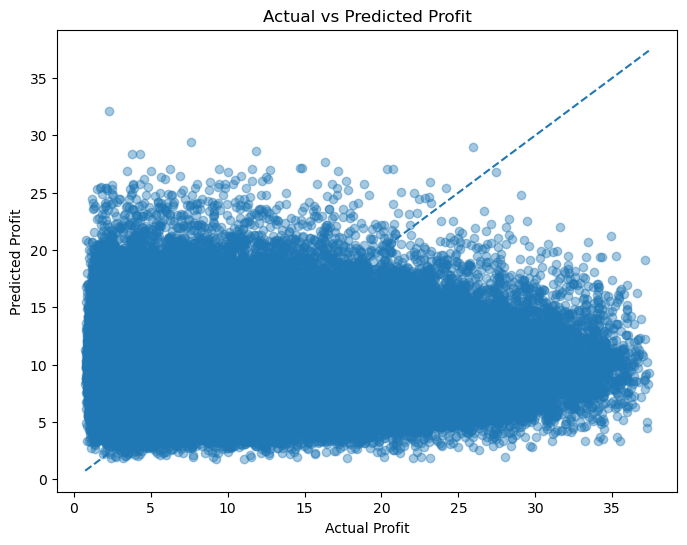

In [49]:
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

In [75]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance = model.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,num__month,0.211421
23,num__day_of_week,0.178917
24,num__loyalty_member,0.056760
20,cat__store_type_Online,0.033813
21,cat__store_type_Retail,0.033174
19,cat__store_type_Mall,0.032848
18,cat__store_type_Airport,0.032675
10,cat__category_White,0.029066
6,cat__category_Dark,0.028285
8,cat__category_Praline,0.028007


In [50]:
data.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,date,year,month,day,week,day_of_week,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2023-01-07,2023,1,7,1,5,44,Male,1,2021-11-17
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-10-22,2023,10,22,42,6,63,Female,1,2023-07-03
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-05-07,2023,5,7,18,6,35,Male,1,2023-10-09
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,2024-06-23,2024,6,23,25,6,37,Female,1,2023-05-30
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,2024-09-24,2024,9,24,39,1,57,Female,0,2021-08-20


In [51]:
data2=data[['brand','category','cocoa_percent','city','store_type','month','year','day_of_week','loyalty_member','age','gender','profit']]

In [52]:
data2.head()

,brand,category,cocoa_percent,city,store_type,month,year,day_of_week,loyalty_member,age,gender,profit
0,Hershey,White,70,Sydney,Airport,1,2023,5,1,44,Male,18.56
1,Lindt,Praline,60,New York,Retail,10,2023,6,1,63,Female,16.97
2,Hershey,Milk,90,London,Airport,5,2023,6,1,35,Male,9.75
3,Godiva,Praline,60,Toronto,Retail,6,2024,6,1,37,Female,10.04
4,Hershey,Truffle,90,London,Online,9,2024,1,0,57,Female,4.40


In [53]:
x=data2[['brand','category','cocoa_percent','city','store_type','month','year','day_of_week','loyalty_member','age','gender']]

In [54]:
Y=data2['profit']

In [55]:
x_train,x_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.2,random_state=32)

In [56]:
categorical_features2=['brand','category','city','store_type','gender']
numerical_features2=['month','day_of_week','loyalty_member','cocoa_percent','year','age']

In [57]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features2),
        ('num', 'passthrough',
         numerical_features2)])

In [58]:
model2= Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=32,
        n_jobs=-1
    ))
])

In [59]:
model2.fit(x_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [60]:
Y_pred = model2.predict(x_test)

In [61]:
mae = mean_absolute_error(Y_test, Y_pred)

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5.67420889656059
RMSE: 6.974521540768115
R² Score: -0.06066670694770959


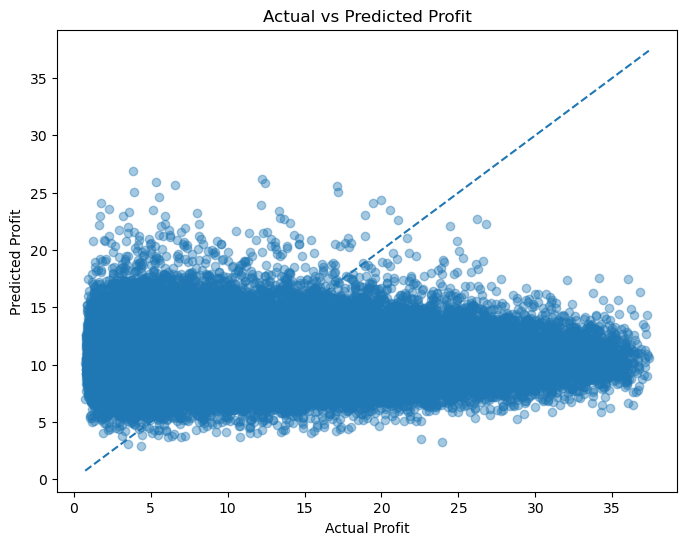

In [62]:
min_value = min(Y_test.min(), Y_pred.min())
max_value = max(Y_test.max(), Y_pred.max())

plt.figure(figsize=(8,6))

plt.scatter(Y_test, Y_pred, alpha=0.4)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

In [73]:
feature_names = model2.named_steps['preprocessor'].get_feature_names_out()

importance = model2.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
29,num__age,0.210100
24,num__month,0.131996
25,num__day_of_week,0.106659
27,num__cocoa_percent,0.075616
28,num__year,0.038234
26,num__loyalty_member,0.033523
18,cat__store_type_Airport,0.021043
23,cat__gender_Male,0.019986
22,cat__gender_Female,0.019940
19,cat__store_type_Mall,0.019858


Now creating another model using the time based RF, for prediction of 2024 profits by training the 2023 sales

In [63]:
data_2023=data[data.year==2023]
data_2024=data[data.year==2024]

In [76]:
x_data_2023=data_2023[['brand','category','cocoa_percent','city','store_type','month','day_of_week','loyalty_member','age','gender']]
y_data_2023=data_2023['profit']

In [77]:
x_data_2024=data_2024[['brand','category','cocoa_percent','city','store_type','month','day_of_week','loyalty_member','age','gender']]
y_data_2024=data_2024['profit']

In [78]:
categorical_features_year=['brand','category','city','store_type','gender']
numerical_features_year=['month','day_of_week','loyalty_member','cocoa_percent','age']

In [79]:
preprocessor_year = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features_year),
        ('num', 'passthrough',
         numerical_features_year)])

In [80]:
model_year= Pipeline(steps=[
    ('preprocessor', preprocessor_year),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=32,
        n_jobs=-1
    ))
])

In [81]:
model_year.fit(x_data_2023,y_data_2023)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [82]:
y_pred_2024=model_year.predict(x_data_2024)

In [83]:
mae = mean_absolute_error(y_data_2024, y_pred_2024)

rmse = np.sqrt(mean_squared_error(y_data_2024, y_pred_2024))

r2 = r2_score(y_data_2024, y_pred_2024)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 5.680663255340175
RMSE: 6.99126278250106
R² Score: -0.06497440743654415


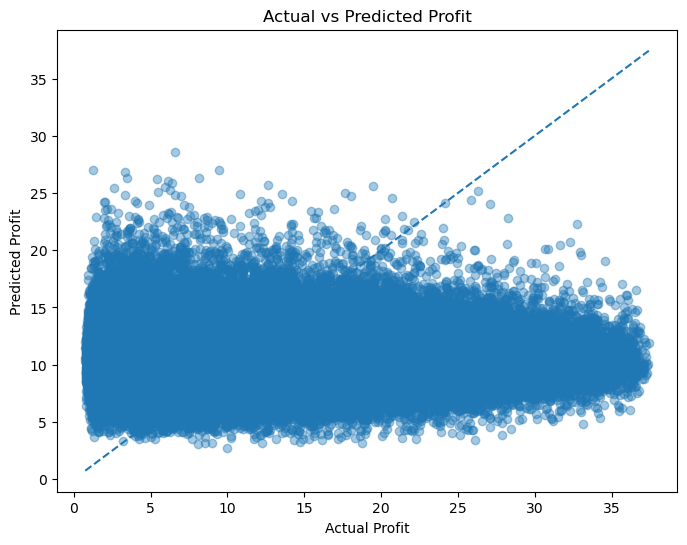

In [84]:
min_value = min(y_data_2024.min(), y_pred_2024.min())
max_value = max(y_data_2024.max(), y_pred_2024.max())

plt.figure(figsize=(8,6))

plt.scatter(y_data_2024, y_pred_2024, alpha=0.4)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

In [85]:
feature_names = model_year.named_steps['preprocessor'].get_feature_names_out()

importance = model_year.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
28,num__age,0.225547
24,num__month,0.140184
25,num__day_of_week,0.107697
27,num__cocoa_percent,0.076088
23,cat__gender_Male,0.021958
18,cat__store_type_Airport,0.021916
22,cat__gender_Female,0.021835
17,cat__city_Toronto,0.020671
19,cat__store_type_Mall,0.019972
8,cat__category_Praline,0.019775
